# Library and Data Imports and Standardization

In [1]:
# # pip install imbalanced-learn
# %pip install imbalanced-learn

In [2]:
# Make the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, make_scorer, r2_score, root_mean_squared_error

# Import train test split
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn import svm
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from pprint import pprint

# Import KNeighbors Regressor and Classifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier

# Import time
import time

# Import Randomized Search CV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Import kfold
from sklearn.model_selection import KFold

# Import cross val score
from sklearn.model_selection import cross_val_score

# Import math
import math

# Import log2
from math import log2

# Import classification report
from sklearn.metrics import classification_report

# Import pickle
import pickle

np.random.seed(42)

# Analyze using permutation importance
from sklearn.inspection import permutation_importance

# Import SMOTE
from imblearn.over_sampling import SMOTE

# Import ImbPipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/'
pickle_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/pickle/'
results_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/'
# path = 'data/'
# pickle_path = 'pickle/'
# results_path = 'results/'

convabuse_filename = 'convabuse_imbalanced.csv'
dghs_filename = 'dynamically_generated_hate_speech_dataset_imbalanced.csv'
oaa_filename = 'online_abusive_attacks_class_imbalanced.csv'
us2020hs_filename = 'us_elections_2020_hate_speech_imbalanced.csv'
mlma_hate_speech_filename = 'MLMA_hate_speech_imbalanced.csv'

In [4]:
# Import the datasets
convabuse = pd.read_csv(f'{path}{convabuse_filename}')
convabuse_sample = convabuse.sample(frac=0.3, random_state=42)
dynamically_generated_hate_speech = pd.read_csv(f'{path}{dghs_filename}')
dghs_sample = dynamically_generated_hate_speech.sample(frac=0.3, random_state=42)
online_abusive_attacks = pd.read_csv(f'{path}{oaa_filename}')
online_abusive_attacks_sample = online_abusive_attacks.sample(frac=0.3, random_state=42)
us_elections_2020_hate_speech = pd.read_csv(f'{path}{us2020hs_filename}')
us2020hs_sample = us_elections_2020_hate_speech.sample(frac=0.3, random_state=42)
mlma_hate_speech = pd.read_csv(f'{path}{mlma_hate_speech_filename}')
mlma_hate_speech_sample = mlma_hate_speech.sample(frac=0.3, random_state=42)

In [5]:
convabuse.head()

,annotator_id,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups
0,7,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,1,0
2,7,0,0,0,0,0,0,0,0
3,7,1,0,0,0,0,0,0,0
4,7,0,0,0,0,0,0,0,0


In [6]:
convabuse_X = convabuse.drop("abuse_level", axis=1)
convabuse_y = convabuse["abuse_level"]
convabuse_X_sample = convabuse_sample.drop("abuse_level", axis=1)
convabuse_y_sample = convabuse_sample["abuse_level"]

In [7]:
dynamically_generated_hate_speech.head()

,label,type,annotator,target_groups,original
0,1.0,0,3,0,1
1,1.0,0,3,0,1
2,1.0,0,18,0,1
3,1.0,0,16,0,1
4,1.0,0,7,0,1


In [8]:
dghs_X = dynamically_generated_hate_speech.drop("label", axis=1)
dghs_y = dynamically_generated_hate_speech["label"]
dghs_X_sample = dghs_sample.drop("label", axis=1)
dghs_y_sample = dghs_sample["label"]

In [9]:
online_abusive_attacks.head()

,Toxic parent tweets,Toxic replies,Toxic Level
0,0.0,0.0,0
1,67.0,13.0,2
2,28.0,45.0,2
3,47.0,49.0,2
4,97.0,7.0,3


In [10]:
online_abusive_attacks_X = online_abusive_attacks.drop("Toxic Level", axis=1)
online_abusive_attacks_y = online_abusive_attacks["Toxic Level"]
online_abusive_attacks_X_sample = online_abusive_attacks_sample.drop("Toxic Level", axis=1)
online_abusive_attacks_y_sample = online_abusive_attacks_sample["Toxic Level"]

In [11]:
us_elections_2020_hate_speech.head()

,Trump,Biden,West,HOF
0,1,0,1,0
1,1,0,1,0
2,-1,0,1,0
3,0,0,1,0
4,0,1,1,0


In [12]:
us2020hs_X = us_elections_2020_hate_speech.drop("HOF", axis=1)
us2020hs_y = us_elections_2020_hate_speech["HOF"]
us2020hs_X_sample = us2020hs_sample.drop("HOF", axis=1)
us2020hs_y_sample = us2020hs_sample["HOF"]

In [13]:
mlma_hate_speech.head()

,implicit,explicit,target_groups,annotator_sentiment,abuse_level
0,1,0,1,2,2
1,1,0,0,6,1
2,1,0,0,0,1
3,0,1,1,0,1
4,1,0,1,0,1


In [14]:
mlma_hate_speech_X = mlma_hate_speech.drop("target_groups", axis=1)
mlma_hate_speech_y = mlma_hate_speech["target_groups"]
mlma_hate_speech_X_sample = mlma_hate_speech_sample.drop("target_groups", axis=1)
mlma_hate_speech_y_sample = mlma_hate_speech_sample["target_groups"]

In [15]:
# Instantiate K Fold for each dataset
convabuse_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
dghs_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
oaa_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
us2020hs_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
mlma_hate_speech_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Linear Modeling

In [16]:
# Get only the numeric features for each dataset
convabuse_X_numeric = convabuse_X.select_dtypes(include=np.number)
convabuse_X_numeric_sample = convabuse_X_sample.select_dtypes(include=np.number)
dghs_X_numeric = dghs_X.select_dtypes(include=np.number)
dghs_X_numeric_sample = dghs_X_sample.select_dtypes(include=np.number)
online_abusive_attacks_X_numeric = online_abusive_attacks_X.select_dtypes(include=np.number)
online_abusive_attacks_X_numeric_sample = online_abusive_attacks_X_sample.select_dtypes(include=np.number)
us2020hs_X_numeric = us2020hs_X.select_dtypes(include=np.number)
us2020hs_X_numeric_sample = us2020hs_X_sample.select_dtypes(include=np.number)
mlma_hate_speech_X_numeric = mlma_hate_speech_X.select_dtypes(include=np.number)
mlma_hate_speech_X_numeric_sample = mlma_hate_speech_X_sample.select_dtypes(include=np.number)

In [17]:
# Use standard scaler on the Convabuse X data
convabuse_scaler = StandardScaler()
convabuse_X_scaled = convabuse_scaler.fit_transform(convabuse_X_numeric)
convabuse_X_scaled = pd.DataFrame(convabuse_X_scaled, columns=convabuse_X_numeric.columns)

In [18]:
# Use standard scaler on the Convabuse X sample data
convabuse_sample_scaler = StandardScaler()
convabuse_X_scaled_sample = convabuse_sample_scaler.fit_transform(convabuse_X_numeric_sample)
convabuse_X_scaled_sample = pd.DataFrame(convabuse_X_scaled_sample, columns=convabuse_X_numeric_sample.columns)

In [19]:
# Use standard scaler on the Dynamically Generated Hate Speech X data
dghs_scaler = StandardScaler()
dghs_X_scaled = dghs_scaler.fit_transform(dghs_X_numeric)
dghs_X_scaled = pd.DataFrame(dghs_X_scaled, columns=dghs_X_numeric.columns)

In [20]:
# Use standard scaler on the Dynamically Generated Hate Speech X sample data
dghs_sample_scaler = StandardScaler()
dghs_X_scaled_sample = dghs_sample_scaler.fit_transform(dghs_X_numeric_sample)
dghs_X_scaled_sample = pd.DataFrame(dghs_X_scaled_sample, columns=dghs_X_numeric_sample.columns)

In [21]:
# Use standard scaler on the online abusive attacks X data
oaa_scaler = StandardScaler()
oaa_X_scaled = oaa_scaler.fit_transform(online_abusive_attacks_X_numeric)
oaa_X_scaled = pd.DataFrame(oaa_X_scaled, columns=online_abusive_attacks_X_numeric.columns)

In [22]:
# Use standard scaler on the online abusive attacks X sample data
oaa_sample_scaler = StandardScaler()
oaa_X_scaled_sample = oaa_sample_scaler.fit_transform(online_abusive_attacks_X_numeric_sample)
oaa_X_scaled_sample = pd.DataFrame(oaa_X_scaled_sample, columns=online_abusive_attacks_X_numeric_sample.columns)

In [23]:
# Use standard scaler on the US elections 2020 hate speech X data
us2020hs_scaler = StandardScaler()
us2020hs_X_scaled = us2020hs_scaler.fit_transform(us2020hs_X_numeric)
us2020hs_X_scaled = pd.DataFrame(us2020hs_X_scaled, columns=us2020hs_X_numeric.columns)

In [24]:
# Use standard scaler on the US elections 2020 hate speech X sample data
us2020hs_sample_scaler = StandardScaler()
us2020hs_X_scaled_sample = us2020hs_sample_scaler.fit_transform(us2020hs_X_numeric_sample)
us2020hs_X_scaled_sample = pd.DataFrame(us2020hs_X_scaled_sample, columns=us2020hs_X_numeric_sample.columns)

In [25]:
# Use standard scaler on the MLMA hate speech X data
mlma_hate_speech_scaler = StandardScaler()
mlma_hate_speech_X_scaled = mlma_hate_speech_scaler.fit_transform(mlma_hate_speech_X_numeric)
mlma_hate_speech_X_scaled = pd.DataFrame(mlma_hate_speech_X_scaled, columns=mlma_hate_speech_X_numeric.columns)

In [26]:
# Use standard scaler on the MLMA hate speech X sample data
mlma_hate_speech_sample_scaler = StandardScaler()
mlma_hate_speech_X_sample_scaled = mlma_hate_speech_sample_scaler.fit_transform(mlma_hate_speech_X_numeric_sample)
mlma_hate_speech_X_sample_scaled = pd.DataFrame(mlma_hate_speech_X_sample_scaled, columns=mlma_hate_speech_X_numeric_sample.columns)

In [27]:
smote = SMOTE(random_state=42)

convabuse_X_resampled, convabuse_y_resampled = smote.fit_resample(convabuse_X_scaled, convabuse_y)
dghs_X_resampled, dghs_y_resampled = smote.fit_resample(dghs_X_scaled, dghs_y)
oaa_X_resampled, oaa_y_resampled = smote.fit_resample(oaa_X_scaled, online_abusive_attacks_y)
us2020hs_X_resampled, us2020hs_y_resampled = smote.fit_resample(us2020hs_X_scaled, us2020hs_y)
mlma_hate_speech_X_resampled, mlma_hate_speech_y_resampled = smote.fit_resample(mlma_hate_speech_X_scaled, mlma_hate_speech_y)

convabuse_X_resampled_sample, convabuse_y_resample_sample = smote.fit_resample(convabuse_X_scaled_sample, convabuse_y_sample)
dghs_X_resampled_sample, dghs_y_resampled_sample = smote.fit_resample(dghs_X_scaled_sample, dghs_y_sample)
oaa_X_resampled_sample, oaa_y_resampled_sample = smote.fit_resample(oaa_X_scaled_sample, online_abusive_attacks_y_sample)
us2020hs_X_resampled_sample, us2020hs_y_resampled_sample = smote.fit_resample(us2020hs_X_scaled_sample, us2020hs_y_sample)
mlma_hate_speech_X_resampled_sample, mlma_hate_speech_y_resampled_sample = smote.fit_resample(mlma_hate_speech_X_sample_scaled, mlma_hate_speech_y_sample)

In [28]:
for columns in [convabuse_X_numeric.columns, dghs_X_numeric.columns, online_abusive_attacks_X_numeric.columns, us2020hs_X_numeric.columns, mlma_hate_speech_X_numeric.columns]:
  print(columns)

Index(['annotator_id', 'bot', 'generalised', 'individual', 'system',
       'explicit', 'implicit', 'target_groups'],
      dtype='object')
Index(['type', 'annotator', 'target_groups', 'original'], dtype='object')
Index(['Toxic parent tweets', 'Toxic replies'], dtype='object')
Index(['Trump', 'Biden', 'West'], dtype='object')
Index(['implicit', 'explicit', 'annotator_sentiment', 'abuse_level'], dtype='object')


In [29]:
# Train test split for each dataset
convabuse_X_train, convabuse_X_test, convabuse_y_train, convabuse_y_test = train_test_split(convabuse_X_resampled, convabuse_y_resampled, test_size=0.2, random_state=42, stratify=convabuse_y_resampled)
convabuse_X_train_sample, convabuse_X_test_sample, convabuse_y_train_sample, convabuse_y_test_sample = train_test_split(convabuse_X_resampled_sample, convabuse_y_resample_sample, test_size=0.2, random_state=42, stratify=convabuse_y_resample_sample)

dghs_X_train, dghs_X_test, dghs_y_train, dghs_y_test = train_test_split(dghs_X_resampled, dghs_y_resampled, test_size=0.2, random_state=42, stratify=dghs_y_resampled)
dghs_X_train_sample, dghs_X_test_sample, dghs_y_train_sample, dghs_y_test_sample = train_test_split(dghs_X_resampled_sample, dghs_y_resampled_sample, test_size=0.2, random_state=42, stratify=dghs_y_resampled_sample)

oaa_X_train, oaa_X_test, oaa_y_train, oaa_y_test = train_test_split(oaa_X_resampled, oaa_y_resampled, test_size=0.2, random_state=42, stratify=oaa_y_resampled)
oaa_X_train_sample, oaa_X_test_sample, oaa_y_train_sample, oaa_y_test_sample = train_test_split(oaa_X_resampled_sample, oaa_y_resampled_sample, test_size=0.2, random_state=42, stratify=oaa_y_resampled_sample)

us2020hs_X_train, us2020hs_X_test, us2020hs_y_train, us2020hs_y_test = train_test_split(us2020hs_X_resampled, us2020hs_y_resampled, test_size=0.2, random_state=42, stratify=us2020hs_y_resampled)
us2020hs_X_train_sample, us2020hs_X_test_sample, us2020hs_y_train_sample, us2020hs_y_test_sample = train_test_split(us2020hs_X_resampled_sample, us2020hs_y_resampled_sample, test_size=0.2, random_state=42, stratify=us2020hs_y_resampled_sample)

mlma_hate_speech_X_train, mlma_hate_speech_X_test, mlma_hate_speech_y_train, mlma_hate_speech_y_test = train_test_split(mlma_hate_speech_X_resampled, mlma_hate_speech_y_resampled, test_size=0.2, random_state=42, stratify=mlma_hate_speech_y_resampled)
mlma_hate_speech_X_train_sample, mlma_hate_speech_X_test_sample, mlma_hate_speech_y_train_sample, mlma_hate_speech_y_test_sample = train_test_split(mlma_hate_speech_X_resampled_sample, mlma_hate_speech_y_resampled_sample, test_size=0.2, random_state=42, stratify=mlma_hate_speech_y_resampled_sample)

In [30]:
# Get the length of each dataset
convabuse_length = len(convabuse_X_train_sample)
dghs_length = len(dghs_X_train_sample)
oaa_length = len(oaa_X_train_sample)
us2020hs_length = len(us2020hs_X_train_sample)
mlma_hate_speech_length = len(mlma_hate_speech_X_train_sample)

In [31]:
convabuse_log2 = math.ceil(log2(convabuse_length))
convabuse_1_percent = math.ceil(convabuse_length * 0.01)
convabuse_length, convabuse_log2, convabuse_1_percent

(12024, 14, 121)

In [32]:
dghs_log2 = math.ceil(log2(dghs_length))
dghs_1_percent = math.ceil(dghs_length * 0.01)
dghs_length, dghs_log2, dghs_1_percent

(10563, 14, 106)

In [33]:
online_abusive_attacks_log2 = math.ceil(log2(oaa_length))
online_abusive_attacks_1_percent = math.ceil(oaa_length * 0.01)
oaa_length, online_abusive_attacks_log2, online_abusive_attacks_1_percent

(1332, 11, 14)

In [34]:
us2020hs_log2 = math.ceil(log2(us2020hs_length))
us2020hs_1_percent = math.ceil(us2020hs_length * 0.01)
us2020hs_length, us2020hs_log2, us2020hs_1_percent

(1275, 11, 13)

In [35]:
mlma_hate_speech_log2 = math.ceil(log2(mlma_hate_speech_length))
mlma_hate_speech_1_percent = math.ceil(mlma_hate_speech_length * 0.01)
mlma_hate_speech_length, mlma_hate_speech_log2, mlma_hate_speech_1_percent

(10403, 14, 105)

In [36]:
# Get the length of 1% of each dataset
convabuse_1_percent = int((len(convabuse_X_train) * 0.01) / 10)
dghs_1_percent = int((len(dghs_X_train) * 0.01) / 10)
online_abusive_attacks_1_percent = int((len(oaa_X_train) * 0.01) / 10)
us2020hs_1_percent = int((len(us2020hs_X_train) * 0.01) / 10)
mlma_hate_speech_1_percent = int((len(mlma_hate_speech_X_train) * 0.01) / 10)
convabuse_1_percent, dghs_1_percent, us2020hs_1_percent, mlma_hate_speech_1_percent

(40, 35, 4, 34)

In [37]:
# Create ranges based on 1% of each dataset length times 10, starting from 1% to 11%
convabuse_k_range = list(range(convabuse_1_percent, convabuse_1_percent * 11, convabuse_1_percent))
dghs_k_range = list(range(dghs_1_percent, dghs_1_percent * 11, dghs_1_percent))
online_abusive_attacks_k_range = list(range(online_abusive_attacks_1_percent, online_abusive_attacks_1_percent * 11, online_abusive_attacks_1_percent))
us2020hs_k_range = list(range(us2020hs_1_percent, us2020hs_1_percent * 11, us2020hs_1_percent))
mlma_hate_speech_k_range = list(range(mlma_hate_speech_1_percent, mlma_hate_speech_1_percent * 11, mlma_hate_speech_1_percent))
convabuse_k_range, dghs_k_range, us2020hs_k_range, mlma_hate_speech_k_range

([40, 80, 120, 160, 200, 240, 280, 320, 360, 400],
 [35, 70, 105, 140, 175, 210, 245, 280, 315, 350],
 [4, 8, 12, 16, 20, 24, 28, 32, 36, 40],
 [34, 68, 102, 136, 170, 204, 238, 272, 306, 340])

In [38]:
knn_classification_results_list = []

In [39]:
balance = 'SMOTE'

## Convabuse Decision Tree

In [40]:
convabuse_y_test.value_counts()

,count
abuse_level,
3,2013
2,2013
0,2013
4,2012
1,2012


In [41]:
# Instantiate the KNN classifier for convabuse
convabuse_knn_classifier = KNeighborsClassifier()

# Create the classifier scorer
convabuse_class_scorer = make_scorer(accuracy_score)

# KNN Classifier pipeline for Convabuse dataset
convabuse_knn_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn_classifier', convabuse_knn_classifier)
])

# Set the parameters for Randomized Search for KNN Classifier on the Convabuse dataset
convabuse_knn_param_grid = {
    'knn_classifier__n_neighbors': convabuse_k_range,
    'knn_classifier__weights': ['uniform', 'distance'],
    'knn_classifier__metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
}

# Grid Search for KNN Classifier on the Convabuse dataset
convabuse_knn_grid_search = GridSearchCV(convabuse_knn_pipeline,
                                          param_grid=convabuse_knn_param_grid,
                                          cv=convabuse_kfold,
                                          scoring=convabuse_class_scorer,
                                          verbose=1,
                                          n_jobs=-1,
                                          error_score='raise')

In [42]:
start_time = time.time()
convabuse_class_scorer = make_scorer(accuracy_score, greater_is_better=True)
convabuse_knn_grid_search.fit(convabuse_X_train_sample, convabuse_y_train_sample)
end_time = time.time()

Fitting 5 folds for each of 80 candidates, totalling 400 fits


In [43]:
print("Best parameters for Convabuse KNN Classifier:", convabuse_knn_grid_search.best_params_)
print("Best score for Convabuse KNN Classifier:", convabuse_knn_grid_search.best_score_)
print("Time taken for Convabuse KNN Classifier Randomized Search:", end_time - start_time)

Best parameters for Convabuse KNN Classifier: {'knn_classifier__metric': 'euclidean', 'knn_classifier__n_neighbors': 40, 'knn_classifier__weights': 'distance'}
Best score for Convabuse KNN Classifier: 0.6654188618414908
Time taken for Convabuse KNN Classifier Randomized Search: 172.28191018104553


In [44]:
# Pickle the convabuse_knn_grid_search
with open(f'{pickle_path}convabuse_knn_grid_search.pkl', 'wb') as f:
    pickle.dump(convabuse_knn_grid_search, f)

In [45]:
# Import the pickled convabuse_knn_grid_search
with open(f'{pickle_path}convabuse_knn_grid_search.pkl', 'rb') as f:
    convabuse_knn_grid_search = pickle.load(f)

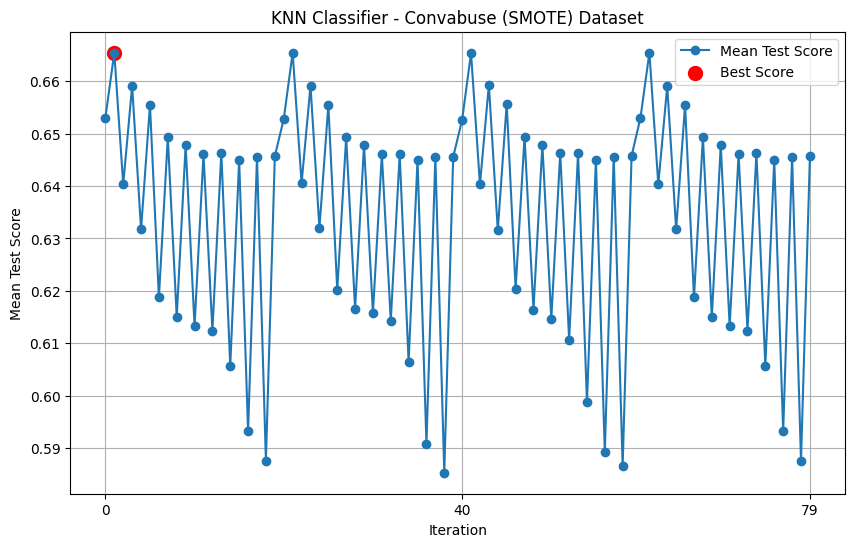

In [46]:
# Plot the accuracy scores for the KNN Classifier on the Convabuse dataset for all iterations
plt.figure(figsize=(10, 6))
plt.plot(convabuse_knn_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot the best score as a red x
convabuse_knn_best_score_index = np.argmax(convabuse_knn_grid_search.cv_results_['mean_test_score'])
plt.scatter(convabuse_knn_best_score_index, convabuse_knn_grid_search.cv_results_['mean_test_score'][convabuse_knn_best_score_index], color='red', s=100, label='Best Score')

plt.title(f'KNN Classifier - Convabuse ({balance}) Dataset')
plt.xlabel('Iteration')
plt.ylabel('Mean Test Score')
# X-ticks at 0, the median value, and the max value
plt.xticks([0, len(convabuse_knn_grid_search.cv_results_['mean_test_score'])//2, len(convabuse_knn_grid_search.cv_results_['mean_test_score'])-1])
plt.legend()
plt.grid()
plt.show()

In [47]:
# Predict on the test set
convabuse_knn_y_pred = convabuse_knn_grid_search.predict(convabuse_X_test)

In [48]:
# Evaluate the model
convabuse_knn_accuracy = accuracy_score(convabuse_y_test, convabuse_knn_y_pred)
convabuse_knn_f1 = f1_score(convabuse_y_test, convabuse_knn_y_pred, average='weighted')

print("Convabuse KNN Classifier:")
print(f"Best Parameters: {convabuse_knn_grid_search.best_params_}")
print(f"Accuracy: {convabuse_knn_accuracy:.4f}")
print(f"F1 Score: {convabuse_knn_f1:.4f}")

Convabuse KNN Classifier:
Best Parameters: {'knn_classifier__metric': 'euclidean', 'knn_classifier__n_neighbors': 40, 'knn_classifier__weights': 'distance'}
Accuracy: 0.5985
F1 Score: 0.5980


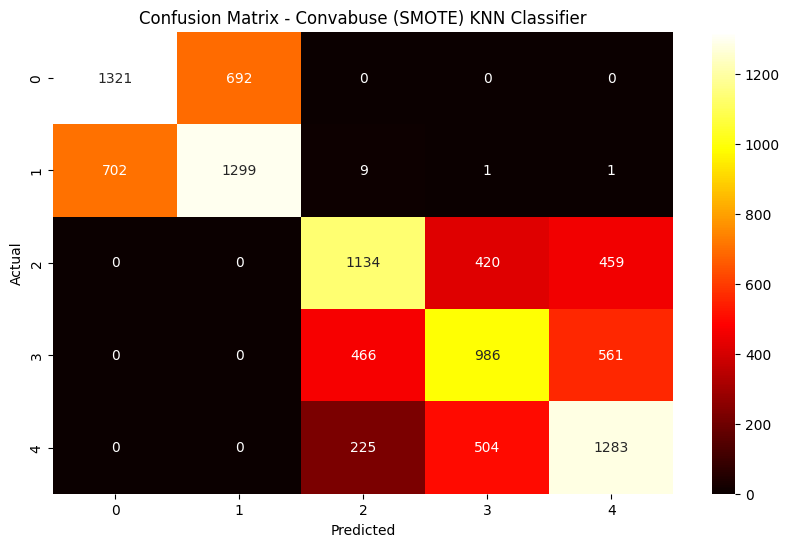

In [49]:
# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(convabuse_y_test, convabuse_knn_y_pred, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix - Convabuse ({balance}) KNN Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [50]:
# Generate a classification report for the KNN Classifier on the Convabuse dataset
convabuse_knn_report = classification_report(convabuse_y_test, convabuse_knn_y_pred)
print("Classification Report for Convabuse KNN Classifier:")
print(convabuse_knn_report)

Classification Report for Convabuse KNN Classifier:
              precision    recall  f1-score   support

           0       0.65      0.66      0.65      2013
           1       0.65      0.65      0.65      2012
           2       0.62      0.56      0.59      2013
           3       0.52      0.49      0.50      2013
           4       0.56      0.64      0.59      2012

    accuracy                           0.60     10063
   macro avg       0.60      0.60      0.60     10063
weighted avg       0.60      0.60      0.60     10063



In [51]:
# Get permutation importance for the Convabuse KNN Classifier
convabuse_knn_result = permutation_importance(convabuse_knn_grid_search, convabuse_X_test, convabuse_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Analyze using feature importances
convabuse_knn_feature_importances = np.sort(convabuse_knn_result.importances_mean)[::-1]
convabuse_knn_feature_importances_dict = {}
for i, col in enumerate(convabuse_X_test.columns):
    convabuse_knn_feature_importances_dict[col] = convabuse_knn_result.importances_mean[i]

convabuse_knn_feature_importances_dict

{'annotator_id': np.float64(0.128947629931432),
 'bot': np.float64(0.029951306767365606),
 'generalised': np.float64(0.0),
 'individual': np.float64(0.0),
 'system': np.float64(0.002275663321077226),
 'explicit': np.float64(0.19551823511875188),
 'implicit': np.float64(0.09889694921991454),
 'target_groups': np.float64(0.018821425022359152)}

In [52]:
# Sort the feature importances dictionary by feature importance from highest to lowest
convabuse_knn_sorted_feature_importances_dict = dict(sorted(convabuse_knn_feature_importances_dict.items(), key=lambda item: item[1], reverse=True))
convabuse_knn_sorted_feature_importances_dict

{'explicit': np.float64(0.19551823511875188),
 'annotator_id': np.float64(0.128947629931432),
 'implicit': np.float64(0.09889694921991454),
 'bot': np.float64(0.029951306767365606),
 'target_groups': np.float64(0.018821425022359152),
 'system': np.float64(0.002275663321077226),
 'generalised': np.float64(0.0),
 'individual': np.float64(0.0)}

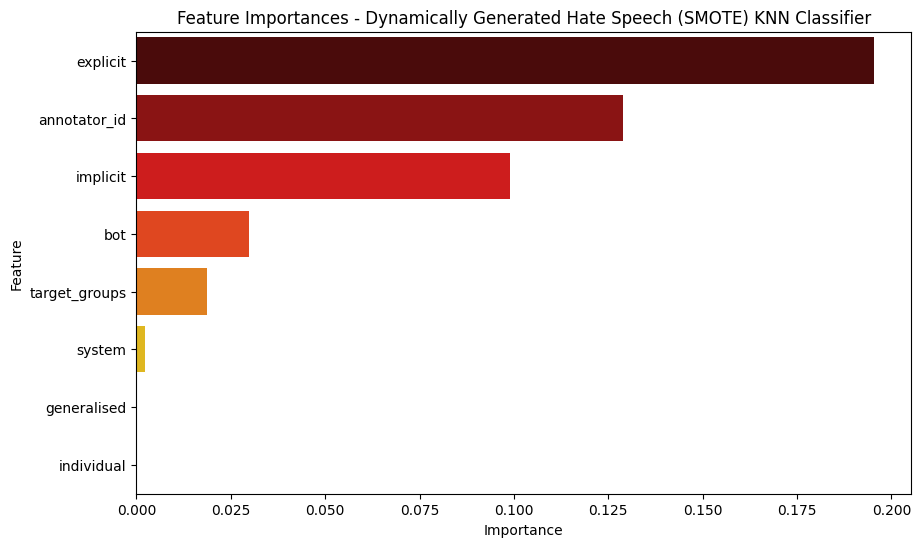

In [53]:
# Convert the sorted importances to a DataFrame and plot them in order
dghs_knn_sorted_importances_df = pd.DataFrame(list(convabuse_knn_sorted_feature_importances_dict.items()), columns=['Feature', 'Importance'])
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=dghs_knn_sorted_importances_df, palette='hot')
plt.title(f'Feature Importances - Dynamically Generated Hate Speech ({balance}) KNN Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [54]:
# Append details to the results list
knn_classification_results_list.append((
    "K-Nearest Neighbors",
    "Convabuse",
    "NA",
    "NA",
    convabuse_knn_accuracy,
    convabuse_knn_f1,
    0.0,
    convabuse_knn_grid_search.best_params_,
    convabuse_knn_feature_importances_dict,
    convabuse_knn_sorted_feature_importances_dict,
    balance
))

## Dynamically Generated Hate Speech Decision Tree

In [55]:
dghs_y_test.value_counts()

,count
label,
1.0,4394
0.0,4394


In [56]:
# Instantiate the KNN classifier for the DGHS dataset
dghs_knn_classifier = KNeighborsClassifier()

# Create the classifier scorer
dghs_class_scorer = make_scorer(accuracy_score)

# KNN Classifier pipeline for DGHS dataset
dghs_knn_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn_classifier', dghs_knn_classifier)
])

# Set the parameters for Randomized Search for KNN Classifier on the DGHS dataset
dghs_knn_param_grid = {
    'knn_classifier__n_neighbors': dghs_k_range,
    'knn_classifier__weights': ['uniform', 'distance'],
    'knn_classifier__metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
}

# Grid Search for KNN Classifier on the DGHS dataset
dghs_knn_grid_search = GridSearchCV(dghs_knn_pipeline,
                                   param_grid=dghs_knn_param_grid,
                                   cv=dghs_kfold,
                                   scoring=dghs_class_scorer,
                                   verbose=1,
                                   n_jobs=-1,
                                   error_score='raise')

In [57]:
start_time = time.time()
dghs_class_scorer = make_scorer(accuracy_score, greater_is_better=True)
dghs_knn_grid_search.fit(dghs_X_train_sample, dghs_y_train_sample)
end_time = time.time()

Fitting 5 folds for each of 80 candidates, totalling 400 fits


In [58]:
print("Best parameters for Dynamically Generated Hate Speech KNN Classifier:", dghs_knn_grid_search.best_params_)
print("Best score for Dynamically Generated Hate Speech KNN Classifier:", dghs_knn_grid_search.best_score_)
print("Time taken for Dynamically Generated Hate Speech KNN Classifier Randomized Search:", end_time - start_time)

Best parameters for Dynamically Generated Hate Speech KNN Classifier: {'knn_classifier__metric': 'euclidean', 'knn_classifier__n_neighbors': 105, 'knn_classifier__weights': 'uniform'}
Best score for Dynamically Generated Hate Speech KNN Classifier: 0.849001984468442
Time taken for Dynamically Generated Hate Speech KNN Classifier Randomized Search: 82.15207123756409


In [59]:
# Pickle the dghs_knn_grid_search
with open(f'{pickle_path}dghs_knn_grid_search.pkl', 'wb') as f:
    pickle.dump(dghs_knn_grid_search, f)

In [60]:
# Import the pickled dghs_knn_grid_search
with open(f'{pickle_path}dghs_knn_grid_search.pkl', 'rb') as f:
    dghs_knn_grid_search = pickle.load(f)

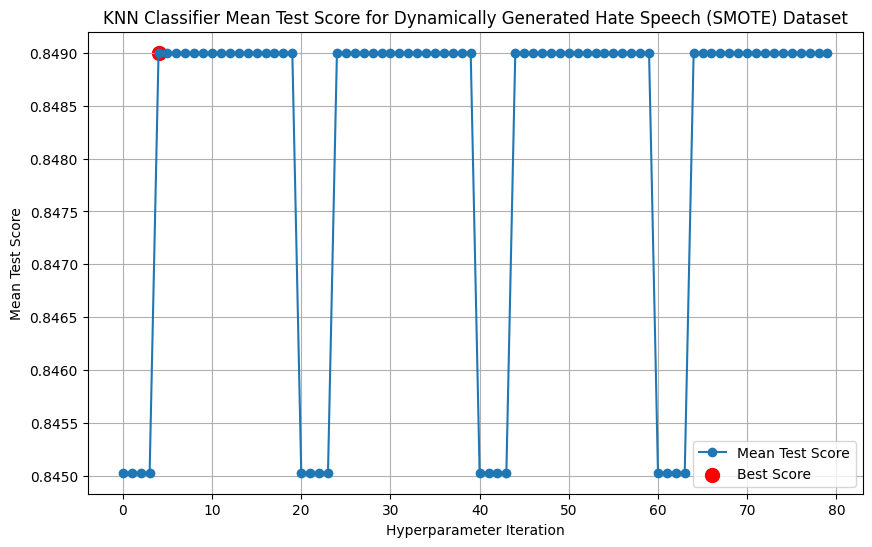

In [61]:
# Plot the accuracy scores for the KNN Classifier on the DGHS dataset for all iterations
plt.figure(figsize=(10, 6))
plt.plot(dghs_knn_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot the best score as a red x
dghs_knn_best_score_index = np.argmax(dghs_knn_grid_search.cv_results_['mean_test_score'])
plt.scatter(dghs_knn_best_score_index, dghs_knn_grid_search.cv_results_['mean_test_score'][dghs_knn_best_score_index], color='red', s=100, label='Best Score')

plt.title(f'KNN Classifier Mean Test Score for Dynamically Generated Hate Speech ({balance}) Dataset')
plt.xlabel('Hyperparameter Iteration')
plt.ylabel('Mean Test Score')
plt.legend()
plt.grid()
plt.show()

In [62]:
# Predict on the test set
dghs_knn_y_pred = dghs_knn_grid_search.predict(dghs_X_test)

In [63]:
# Evaluate the model
dghs_knn_accuracy = accuracy_score(dghs_y_test, dghs_knn_y_pred)
dghs_knn_f1 = f1_score(dghs_y_test, dghs_knn_y_pred, average='weighted')
print("Dynamically Generated Hate Speech KNN Classifier:")
print(f"Best Parameters: {dghs_knn_grid_search.best_params_}")
print(f"Accuracy: {dghs_knn_accuracy:.4f}")
print(f"F1 Score: {dghs_knn_f1:.4f}")

Dynamically Generated Hate Speech KNN Classifier:
Best Parameters: {'knn_classifier__metric': 'euclidean', 'knn_classifier__n_neighbors': 105, 'knn_classifier__weights': 'uniform'}
Accuracy: 0.8458
F1 Score: 0.8445


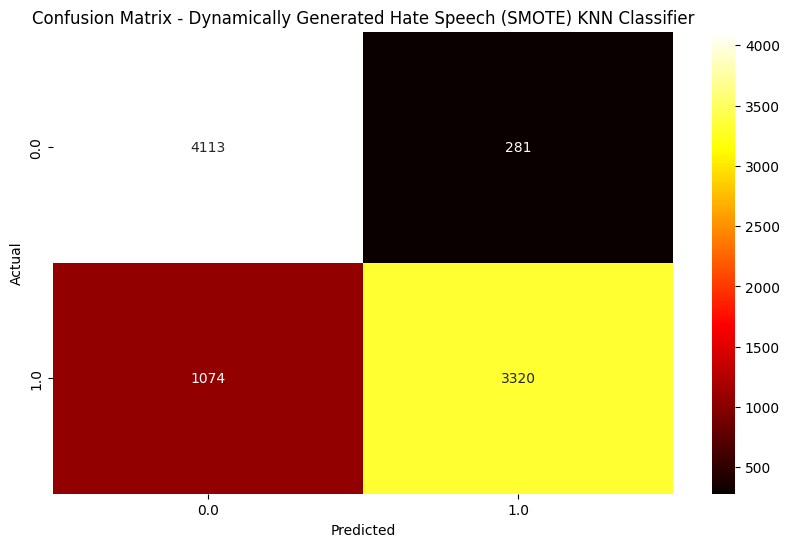

In [64]:
# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(dghs_y_test, dghs_knn_y_pred, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix - Dynamically Generated Hate Speech ({balance}) KNN Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [65]:
# Generate a classification report for the KNN Classifier on the DGHS dataset
dghs_knn_report = classification_report(dghs_y_test, dghs_knn_y_pred)
print("Classification Report for Dynamically Generated Hate Speech KNN Classifier:")
print(dghs_knn_report)

Classification Report for Dynamically Generated Hate Speech KNN Classifier:
              precision    recall  f1-score   support

         0.0       0.79      0.94      0.86      4394
         1.0       0.92      0.76      0.83      4394

    accuracy                           0.85      8788
   macro avg       0.86      0.85      0.84      8788
weighted avg       0.86      0.85      0.84      8788



In [66]:
# Get permutation importance for the DGHS KNN Classifier
dghs_knn_result = permutation_importance(dghs_knn_grid_search, dghs_X_test, dghs_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Analyze using feature importances
dghs_knn_feature_importances = np.sort(dghs_knn_result.importances_mean)[::-1]
dghs_knn_feature_importances_dict = {}
for i, col in enumerate(dghs_X_test.columns):
    dghs_knn_feature_importances_dict[col] = dghs_knn_result.importances_mean[i]
dghs_knn_feature_importances_dict

{'type': np.float64(0.18165680473372778),
 'annotator': np.float64(0.0256144742831133),
 'target_groups': np.float64(0.08065543923532084),
 'original': np.float64(0.012619481110605324)}

In [67]:
# Sort the permutation importances
dghs_knn_sorted_feature_importances_dict = dict(sorted(dghs_knn_feature_importances_dict.items(), key=lambda item: item[1], reverse=True))
dghs_knn_sorted_feature_importances_dict

{'type': np.float64(0.18165680473372778),
 'target_groups': np.float64(0.08065543923532084),
 'annotator': np.float64(0.0256144742831133),
 'original': np.float64(0.012619481110605324)}

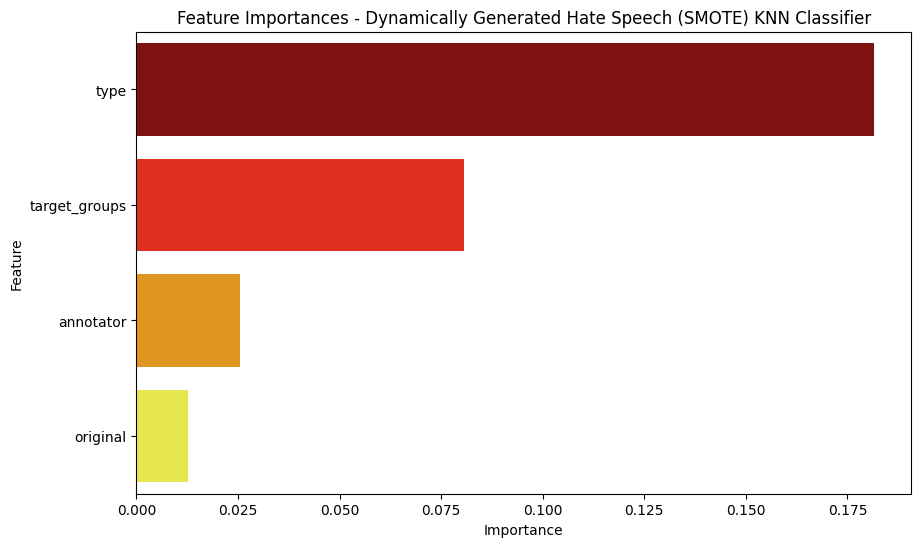

In [68]:
# Convert the sorted importances to a DataFrame and plot them in order
dghs_knn_sorted_importances_df = pd.DataFrame(list(dghs_knn_sorted_feature_importances_dict.items()), columns=['Feature', 'Importance'])
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=dghs_knn_sorted_importances_df, palette='hot')
plt.title(f'Feature Importances - Dynamically Generated Hate Speech ({balance}) KNN Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [69]:
# Append details to the results list
knn_classification_results_list.append((
    "K-Nearest Neighbors",
    "Dynamically Generated Hate Speech",
    "NA",
    "NA",
    dghs_knn_accuracy,
    dghs_knn_f1,
    0.0,
    dghs_knn_grid_search.best_params_,
    dghs_knn_feature_importances_dict,
    dghs_knn_sorted_feature_importances_dict,
    balance
))

In [70]:
oaa_y_test.value_counts()

,count
Toxic Level,
0,223
3,223
4,222
2,222
1,222


In [71]:
# Instantiate the KNN Classifier for the Online Abusive Attacks dataset
oaa_knn_classifier = KNeighborsClassifier()

oaa_reg_scorer = make_scorer(accuracy_score)

# KNN Classifier pipeline for Online Abusive Attacks dataset
oaa_knn_pipeline = Pipeline([
    ('knn_classifier', oaa_knn_classifier)
])

# Set the parameters for Randomized Search for KNN Classifier on the Online Abusive Attacks dataset
oaa_knn_param_grid = {
    'knn_classifier__n_neighbors': online_abusive_attacks_k_range,
    'knn_classifier__weights': ['uniform', 'distance'],
    'knn_classifier__metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
}

# Grid Search for KNN Classifier on the Online Abusive Attacks dataset
oaa_knn_grid_search = GridSearchCV(oaa_knn_pipeline,
                                  param_grid=oaa_knn_param_grid,
                                  cv=5,
                                  scoring=oaa_reg_scorer,
                                  verbose=1,
                                  n_jobs=-1,
                                  error_score='raise')

In [72]:
start_time = time.time()
oaa_knn_grid_search.fit(oaa_X_train, oaa_y_train)
end_time = time.time()

Fitting 5 folds for each of 80 candidates, totalling 400 fits


In [73]:
print("Best parameters for Online Abusive Attacks KNN Classifier:", oaa_knn_grid_search.best_params_)
print("Best score for Online Abusive Attacks KNN Classifier:", oaa_knn_grid_search.best_score_)
print("Time taken for Online Abusive Attacks KNN Classifier Randomized Search:", end_time - start_time)

Best parameters for Online Abusive Attacks KNN Classifier: {'knn_classifier__metric': 'euclidean', 'knn_classifier__n_neighbors': 4, 'knn_classifier__weights': 'distance'}
Best score for Online Abusive Attacks KNN Classifier: 0.9979767697577128
Time taken for Online Abusive Attacks KNN Classifier Randomized Search: 5.855944871902466


In [74]:
# Pickle the oaa_knn_grid_search
with open(f'{pickle_path}oaa_knn_grid_search.pkl', 'wb') as f:
    pickle.dump(oaa_knn_grid_search, f)

In [75]:
# Import the pickled oaa_knn_grid_search
with open(f'{pickle_path}oaa_knn_grid_search.pkl', 'rb') as f:
    oaa_knn_grid_search = pickle.load(f)

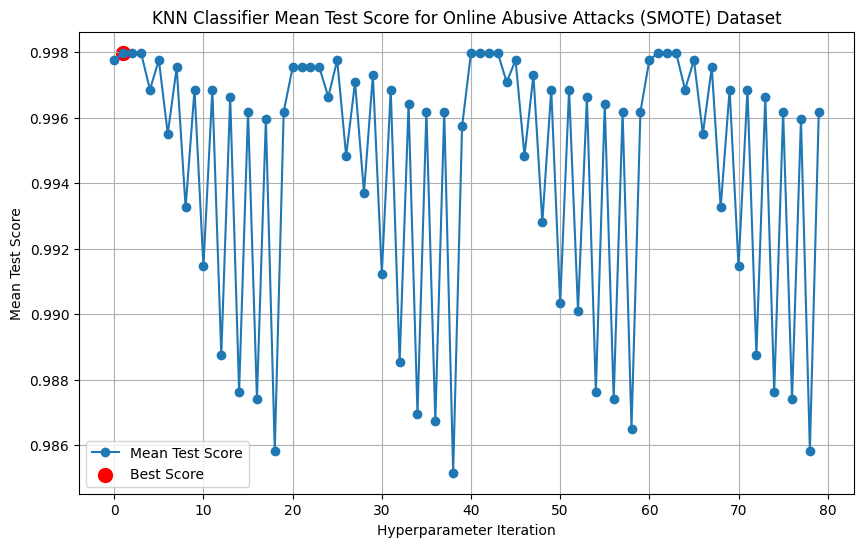

In [76]:
# Plot the accuracy scores for the KNN Classifier on the Online Abusive Attacks dataset for all iterations
plt.figure(figsize=(10, 6))
plt.plot(oaa_knn_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot the best score as a red x
oaa_knn_best_score_index = np.argmax(oaa_knn_grid_search.cv_results_['mean_test_score'])
plt.scatter(oaa_knn_best_score_index, oaa_knn_grid_search.cv_results_['mean_test_score'][oaa_knn_best_score_index], color='red', s=100, label='Best Score')

plt.title(f'KNN Classifier Mean Test Score for Online Abusive Attacks ({balance}) Dataset')
plt.xlabel('Hyperparameter Iteration')
plt.ylabel('Mean Test Score')
plt.legend()
plt.grid()
plt.show()

In [77]:
# Predict on the test set
oaa_knn_y_pred = oaa_knn_grid_search.predict(oaa_X_test)

In [78]:
# Evaluate the model
oaa_knn_accuracy = accuracy_score(oaa_y_test, oaa_knn_y_pred)
oaa_knn_f1 = f1_score(oaa_y_test, oaa_knn_y_pred, average='weighted')
print("Online Abusive Attacks KNN Classifier:")
print(f"Best Parameters: {oaa_knn_grid_search.best_params_}")
print(f"Accuracy: {oaa_knn_accuracy:.4f}")
print(f"F1 Score: {oaa_knn_f1:.4f}")

Online Abusive Attacks KNN Classifier:
Best Parameters: {'knn_classifier__metric': 'euclidean', 'knn_classifier__n_neighbors': 4, 'knn_classifier__weights': 'distance'}
Accuracy: 0.9973
F1 Score: 0.9973


In [79]:
# Generate a classification report for the KNN Classifier on the Online Abusive Attacks dataset
oaa_knn_report = classification_report(oaa_y_test, oaa_knn_y_pred, target_names=['Not Abuse', 'Slightly Abusive', 'Abusive', 'Very Abusive', 'Extremely Abusive'])
print("Classification Report for Online Abusive Attacks KNN Classifier:")
print(oaa_knn_report)

Classification Report for Online Abusive Attacks KNN Classifier:
                   precision    recall  f1-score   support

        Not Abuse       1.00      1.00      1.00       223
 Slightly Abusive       1.00      0.99      0.99       222
          Abusive       0.99      1.00      0.99       222
     Very Abusive       1.00      1.00      1.00       223
Extremely Abusive       1.00      1.00      1.00       222

         accuracy                           1.00      1112
        macro avg       1.00      1.00      1.00      1112
     weighted avg       1.00      1.00      1.00      1112



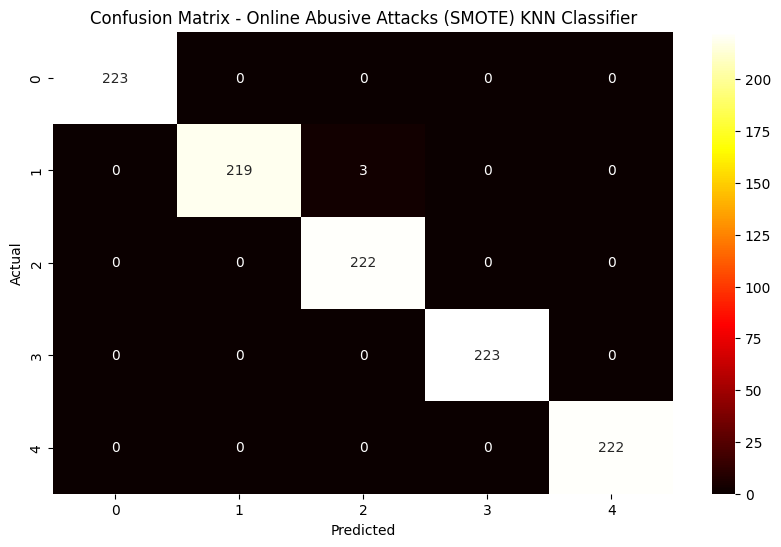

In [80]:
# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(oaa_y_test, oaa_knn_y_pred, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix - Online Abusive Attacks ({balance}) KNN Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [81]:
# Get permutation importance for the Online Abusive Attacks KNN Classifier
oaa_knn_result = permutation_importance(oaa_knn_grid_search, oaa_X_test, oaa_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Analyze using feature importances
oaa_knn_feature_importances = np.sort(oaa_knn_result.importances_mean)[::-1]
oaa_knn_feature_importances_dict = {}
for i, col in enumerate(oaa_X_test.columns):
    oaa_knn_feature_importances_dict[col] = oaa_knn_result.importances_mean[i]
oaa_knn_feature_importances_dict

{'Toxic parent tweets': np.float64(0.7241906474820143),
 'Toxic replies': np.float64(0.30458633093525184)}

In [82]:
# Sort the permutation importances and retain only the top 10 features
oaa_knn_sorted_feature_importances_dict = dict(sorted(oaa_knn_feature_importances_dict.items(), key=lambda item: item[1], reverse=True))
oaa_knn_sorted_feature_importances_dict = {k: oaa_knn_sorted_feature_importances_dict[k] for k in list(oaa_knn_sorted_feature_importances_dict)[:10]}
oaa_knn_sorted_feature_importances_dict

{'Toxic parent tweets': np.float64(0.7241906474820143),
 'Toxic replies': np.float64(0.30458633093525184)}

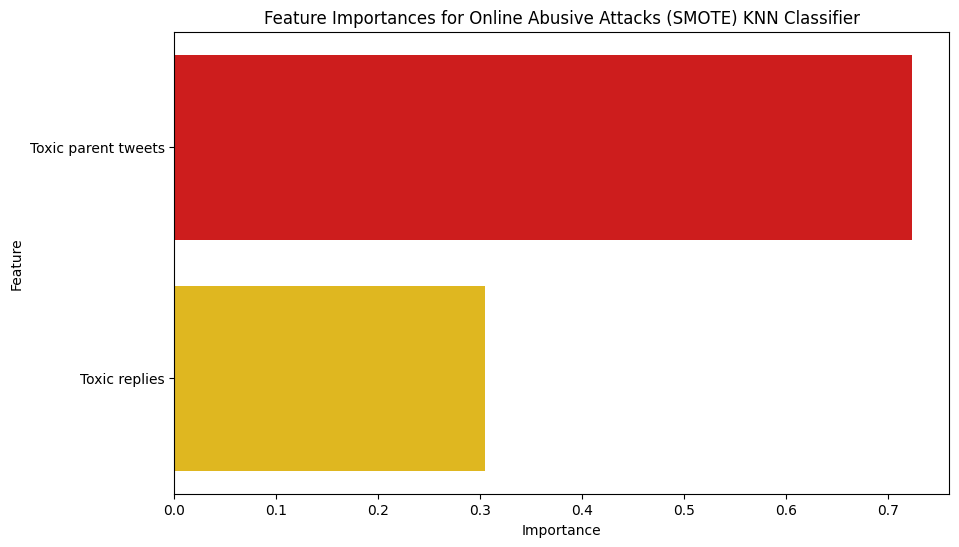

In [83]:
# Convert the sorted importances to a DataFrame and plot the top 10
oaa_knn_sorted_importances_df = pd.DataFrame(list(oaa_knn_sorted_feature_importances_dict.items()), columns=['Feature', 'Importance'])
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=oaa_knn_sorted_importances_df, palette='hot')
plt.title(f'Feature Importances for Online Abusive Attacks ({balance}) KNN Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [84]:
# Append details to the results list
knn_classification_results_list.append((
    "K-Nearest Neighbors",
    "Online Abusive Attacks",
    "NA",
    "NA",
    oaa_knn_accuracy,
    oaa_knn_f1,
    0.0,
    oaa_knn_grid_search.best_params_,
    oaa_knn_feature_importances_dict,
    oaa_knn_sorted_feature_importances_dict
))

In [85]:
us2020hs_y_test.value_counts()

,count
HOF,
1,528
0,528


In [86]:
# Instantiate the KNN classifier for the US Elections 2020 Hate Speech dataset
us2020hs_knn_classifier = KNeighborsClassifier()

# Create the classifier scorer
us2020hs_class_scorer = make_scorer(accuracy_score)

# KNN Classifier pipeline for US Elections 2020 Hate Speech dataset
us2020hs_knn_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn_classifier', us2020hs_knn_classifier)
])

# Set the parameters for Randomized Search for KNN Classifier on the US Elections 2020 Hate Speech dataset
us2020hs_knn_param_grid = {
    'knn_classifier__n_neighbors': us2020hs_k_range,
    'knn_classifier__weights': ['uniform', 'distance'],
    'knn_classifier__metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
}

# Grid Search for KNN Classifier on the US Elections 2020 Hate Speech dataset
us2020hs_knn_grid_search = GridSearchCV(us2020hs_knn_pipeline,
                                       param_grid=us2020hs_knn_param_grid,
                                       cv=us2020hs_kfold,
                                       scoring=us2020hs_class_scorer,
                                       verbose=1,
                                       n_jobs=-1,
                                       error_score='raise')

In [87]:
start_time = time.time()
us2020hs_class_scorer = make_scorer(accuracy_score, greater_is_better=True)
us2020hs_knn_grid_search.fit(us2020hs_X_train_sample, us2020hs_y_train_sample)
end_time = time.time()

Fitting 5 folds for each of 80 candidates, totalling 400 fits


In [88]:
print("Best parameters for US Elections 2020 Hate Speech KNN Classifier:", us2020hs_knn_grid_search.best_params_)
print("Best score for US Elections 2020 Hate Speech KNN Classifier:", us2020hs_knn_grid_search.best_score_)
print("Time taken for US Elections 2020 Hate Speech KNN Classifier Randomized Search:", end_time - start_time)

Best parameters for US Elections 2020 Hate Speech KNN Classifier: {'knn_classifier__metric': 'euclidean', 'knn_classifier__n_neighbors': 16, 'knn_classifier__weights': 'distance'}
Best score for US Elections 2020 Hate Speech KNN Classifier: 0.6980392156862745
Time taken for US Elections 2020 Hate Speech KNN Classifier Randomized Search: 5.052618503570557


In [89]:
# Pickle the us2020hs_knn_grid_search
with open(f'{pickle_path}us2020hs_knn_grid_search.pkl', 'wb') as f:
    pickle.dump(us2020hs_knn_grid_search, f)

In [90]:
# Import the pickled us2020hs_knn_grid_search
with open(f'{pickle_path}us2020hs_knn_grid_search.pkl', 'rb') as f:
    us2020hs_knn_grid_search = pickle.load(f)

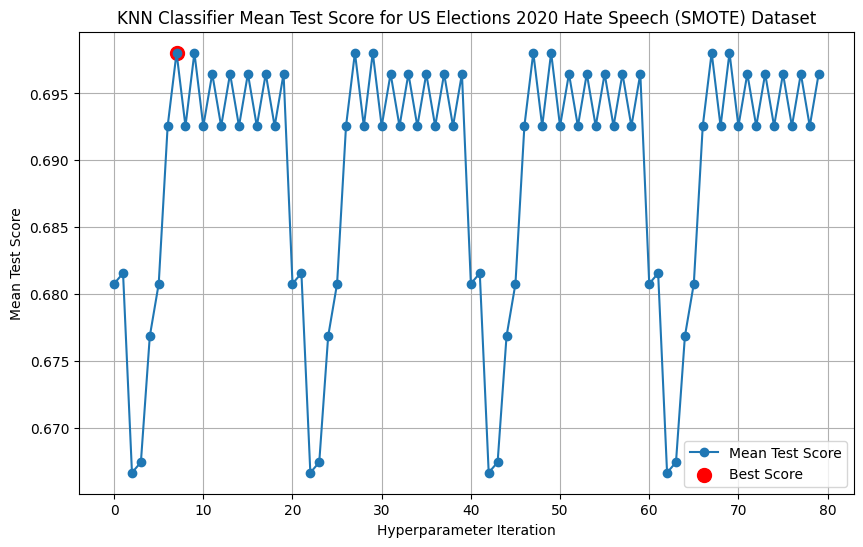

In [91]:
# Plot the accuracy scores for the KNN Classifier on the US Elections 2020 Hate Speech dataset for all iterations
plt.figure(figsize=(10, 6))
plt.plot(us2020hs_knn_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot the best score as a red x
us2020hs_knn_best_score_index = np.argmax(us2020hs_knn_grid_search.cv_results_['mean_test_score'])
plt.scatter(us2020hs_knn_best_score_index, us2020hs_knn_grid_search.cv_results_['mean_test_score'][us2020hs_knn_best_score_index], color='red', s=100, label='Best Score')

plt.title(f'KNN Classifier Mean Test Score for US Elections 2020 Hate Speech ({balance}) Dataset')
plt.xlabel('Hyperparameter Iteration')
plt.ylabel('Mean Test Score')
plt.legend()
plt.grid()
plt.show()

In [92]:
# Predict on the test set
us2020hs_knn_y_pred = us2020hs_knn_grid_search.predict(us2020hs_X_test)

In [93]:
# Evaluate the model
us2020hs_knn_accuracy = accuracy_score(us2020hs_y_test, us2020hs_knn_y_pred)
us2020hs_knn_f1 = f1_score(us2020hs_y_test, us2020hs_knn_y_pred, average='weighted')
print("US Elections 2020 Hate Speech KNN Classifier:")
print(f"Best Parameters: {us2020hs_knn_grid_search.best_params_}")
print(f"Accuracy: {us2020hs_knn_accuracy:.4f}")
print(f"F1 Score: {us2020hs_knn_f1:.4f}")

US Elections 2020 Hate Speech KNN Classifier:
Best Parameters: {'knn_classifier__metric': 'euclidean', 'knn_classifier__n_neighbors': 16, 'knn_classifier__weights': 'distance'}
Accuracy: 0.7036
F1 Score: 0.7025


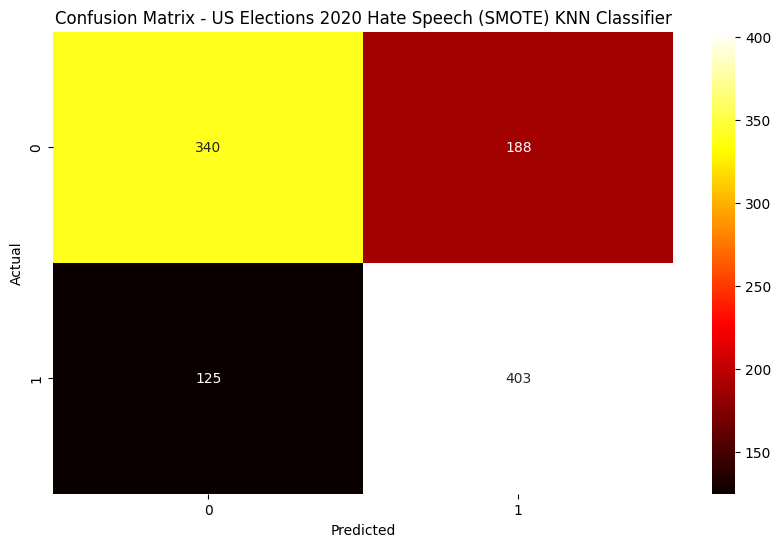

In [94]:
# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(us2020hs_y_test, us2020hs_knn_y_pred, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix - US Elections 2020 Hate Speech ({balance}) KNN Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [95]:
# Generate a classification report for the KNN Classifier on the US Elections 2020 Hate Speech dataset
us2020hs_knn_report = classification_report(us2020hs_y_test, us2020hs_knn_y_pred)
print("Classification Report for US Elections 2020 Hate Speech KNN Classifier:")
print(us2020hs_knn_report)

Classification Report for US Elections 2020 Hate Speech KNN Classifier:
              precision    recall  f1-score   support

           0       0.73      0.64      0.68       528
           1       0.68      0.76      0.72       528

    accuracy                           0.70      1056
   macro avg       0.71      0.70      0.70      1056
weighted avg       0.71      0.70      0.70      1056



In [96]:
# Get permutation importance for the US Elections 2020 Hate Speech KNN Classifier
us_elections_knn_result = permutation_importance(us2020hs_knn_grid_search, us2020hs_X_test, us2020hs_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Analyze using feature importances
us_elections_knn_feature_importances = np.sort(us_elections_knn_result.importances_mean)[::-1]
us_elections_knn_feature_importances_dict = {}
for i, col in enumerate(us2020hs_X_test.columns):
    us_elections_knn_feature_importances_dict[col] = us_elections_knn_result.importances_mean[i]
us_elections_knn_feature_importances_dict

{'Trump': np.float64(0.16704545454545455),
 'Biden': np.float64(0.15776515151515152),
 'West': np.float64(0.0)}

In [97]:
# Sort the importances
us_elections_knn_sorted_feature_importances_dict = dict(sorted(us_elections_knn_feature_importances_dict.items(), key=lambda item: item[1], reverse=True))
us_elections_knn_sorted_feature_importances_dict

{'Trump': np.float64(0.16704545454545455),
 'Biden': np.float64(0.15776515151515152),
 'West': np.float64(0.0)}

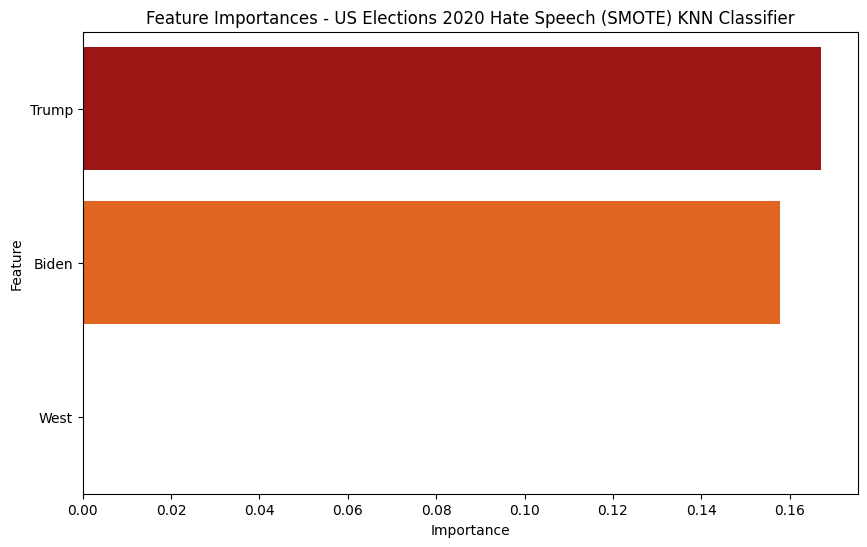

In [98]:
# Plot the sorted importances
us_elections_knn_sorted_importances_df = pd.DataFrame(list(us_elections_knn_sorted_feature_importances_dict.items()), columns=['Feature', 'Importance'])
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=us_elections_knn_sorted_importances_df, palette='hot')
plt.title(f'Feature Importances - US Elections 2020 Hate Speech ({balance}) KNN Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [99]:
# Append details to the results list
knn_classification_results_list.append((
    "K-Nearest Neighbors",
    "US Elections 2020 Hate Speech",
    "NA",
    "NA",
    us2020hs_knn_accuracy,
    us2020hs_knn_f1,
    0.0,
    us2020hs_knn_grid_search.best_params_,
    us_elections_knn_feature_importances_dict,
    us_elections_knn_sorted_feature_importances_dict,
    balance
))

In [100]:
mlma_hate_speech_y_test.value_counts()

,count
target_groups,
1,2168
0,2168
2,2168
3,2168


In [101]:
# Instantiate the KNN classifier for the MLMA Hate Speech dataset
mlma_hate_speech_knn_classifier = KNeighborsClassifier()

# Create the classifier scorer
mlma_hate_speech_class_scorer = make_scorer(accuracy_score)

# KNN Classifier pipeline for MLMA Hate Speech dataset
mlma_hate_speech_knn_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn_classifier', mlma_hate_speech_knn_classifier)
])

# Set the parameters for Randomized Search for KNN Classifier on the MLMA Hate Speech dataset
mlma_hate_speech_knn_param_grid = {
    'knn_classifier__n_neighbors': mlma_hate_speech_k_range,
    'knn_classifier__weights': ['uniform', 'distance'],
    'knn_classifier__metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
}

# Grid Search for KNN Classifier on the MLMA Hate Speech dataset
mlma_hate_speech_knn_grid_search = GridSearchCV(mlma_hate_speech_knn_pipeline,
                                                param_grid=mlma_hate_speech_knn_param_grid,
                                                cv=mlma_hate_speech_kfold,
                                                scoring=mlma_hate_speech_class_scorer,
                                                verbose=1,
                                                n_jobs=-1,
                                                error_score='raise')


In [102]:
start_time = time.time()
mlma_hate_speech_class_scorer = make_scorer(accuracy_score, greater_is_better=True)
mlma_hate_speech_knn_grid_search.fit(mlma_hate_speech_X_train_sample, mlma_hate_speech_y_train_sample)
end_time = time.time()

Fitting 5 folds for each of 80 candidates, totalling 400 fits


In [103]:
print("Best parameters for MLMA Hate Speech KNN Classifier:", mlma_hate_speech_knn_grid_search.best_params_)
print("Best score for MLMA Hate Speech KNN Classifier:", mlma_hate_speech_knn_grid_search.best_score_)
print("Time taken for MLMA Hate Speech KNN Classifier Randomized Search:", end_time - start_time)

Best parameters for MLMA Hate Speech KNN Classifier: {'knn_classifier__metric': 'manhattan', 'knn_classifier__n_neighbors': 102, 'knn_classifier__weights': 'distance'}
Best score for MLMA Hate Speech KNN Classifier: 0.4850503641000998
Time taken for MLMA Hate Speech KNN Classifier Randomized Search: 89.52619051933289


In [104]:
# Pickle the mlma_hate_speech_knn_grid_search
with open(f'{pickle_path}mlma_hate_speech_knn_grid_search.pkl', 'wb') as f:
    pickle.dump(mlma_hate_speech_knn_grid_search, f)

In [105]:
# Import the pickled mlma_hate_speech_knn_grid_search
with open(f'{pickle_path}mlma_hate_speech_knn_grid_search.pkl', 'rb') as f:
    mlma_hate_speech_knn_grid_search = pickle.load(f)

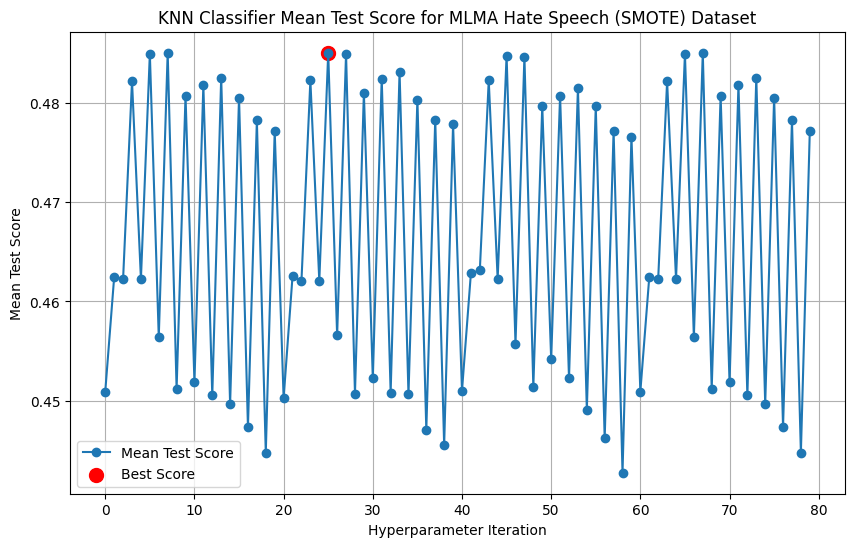

In [106]:
# Plot the accuracy scores for the KNN Classifier on the MLMA Hate Speech dataset for all iterations
plt.figure(figsize=(10, 6))
plt.plot(mlma_hate_speech_knn_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot the best score as a red x
mlma_hate_speech_knn_best_score_index = np.argmax(mlma_hate_speech_knn_grid_search.cv_results_['mean_test_score'])
plt.scatter(mlma_hate_speech_knn_best_score_index, mlma_hate_speech_knn_grid_search.cv_results_['mean_test_score'][mlma_hate_speech_knn_best_score_index], color='red', s=100, label='Best Score')

plt.title(f'KNN Classifier Mean Test Score for MLMA Hate Speech ({balance}) Dataset')
plt.xlabel('Hyperparameter Iteration')
plt.ylabel('Mean Test Score')
plt.legend()
plt.grid()
plt.show()

In [107]:
# Predict on the test set
mlma_hate_speech_knn_y_pred = mlma_hate_speech_knn_grid_search.predict(mlma_hate_speech_X_test)

In [108]:
# Evaluate the model
mlma_hate_speech_knn_accuracy = accuracy_score(mlma_hate_speech_y_test, mlma_hate_speech_knn_y_pred)
mlma_hate_speech_knn_f1 = f1_score(mlma_hate_speech_y_test, mlma_hate_speech_knn_y_pred, average='weighted')
print("MLMA Hate Speech KNN Classifier:")
print(f"Best Parameters: {mlma_hate_speech_knn_grid_search.best_params_}")
print(f"Accuracy: {mlma_hate_speech_knn_accuracy:.4f}")
print(f"F1 Score: {mlma_hate_speech_knn_f1:.4f}")

MLMA Hate Speech KNN Classifier:
Best Parameters: {'knn_classifier__metric': 'manhattan', 'knn_classifier__n_neighbors': 102, 'knn_classifier__weights': 'distance'}
Accuracy: 0.4463
F1 Score: 0.4403


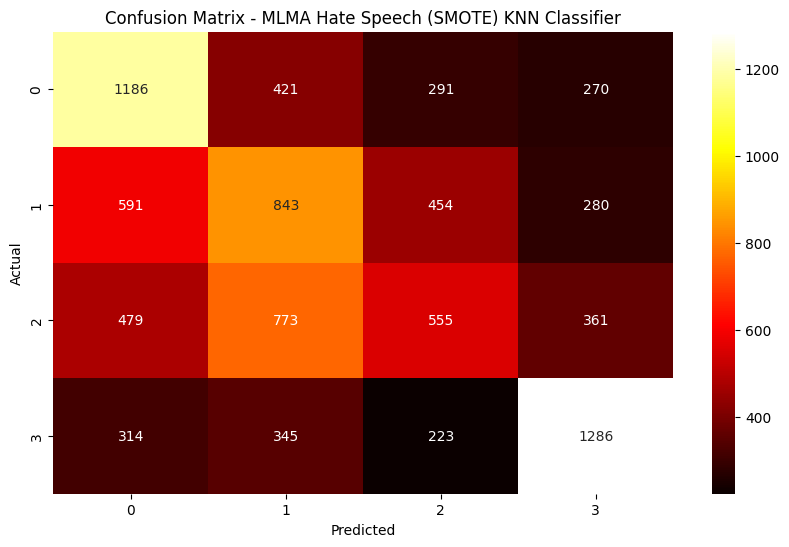

In [109]:
# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(mlma_hate_speech_y_test, mlma_hate_speech_knn_y_pred, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix - MLMA Hate Speech ({balance}) KNN Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [110]:
# Generate a classification report for the KNN Classifier on the MLMA Hate Speech dataset
mlma_hate_speech_knn_report = classification_report(mlma_hate_speech_y_test, mlma_hate_speech_knn_y_pred)
print("Classification Report for MLMA Hate Speech KNN Classifier:")
print(mlma_hate_speech_knn_report)

Classification Report for MLMA Hate Speech KNN Classifier:
              precision    recall  f1-score   support

           0       0.46      0.55      0.50      2168
           1       0.35      0.39      0.37      2168
           2       0.36      0.26      0.30      2168
           3       0.59      0.59      0.59      2168

    accuracy                           0.45      8672
   macro avg       0.44      0.45      0.44      8672
weighted avg       0.44      0.45      0.44      8672



In [111]:
# Get permutation importance for the MLMA Hate Speech KNN Classifier
mlma_hate_speech_knn_result = permutation_importance(mlma_hate_speech_knn_grid_search, mlma_hate_speech_X_test, mlma_hate_speech_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Analyze using feature importances
mlma_hate_speech_knn_feature_importances = np.sort(mlma_hate_speech_knn_result.importances_mean)[::-1]
mlma_hate_speech_knn_feature_importances_dict = {}
for i, col in enumerate(mlma_hate_speech_X_test.columns):
    mlma_hate_speech_knn_feature_importances_dict[col] = mlma_hate_speech_knn_result.importances_mean[i]
mlma_hate_speech_knn_feature_importances_dict

{'implicit': np.float64(0.07315498154981552),
 'explicit': np.float64(0.07315498154981552),
 'annotator_sentiment': np.float64(0.10702260147601476),
 'abuse_level': np.float64(0.027882841328413295)}

In [112]:
# Sort the permutation importances dictionary by feature importance from highest to lowest
mlma_hate_speech_knn_sorted_feature_importances_dict = dict(sorted(mlma_hate_speech_knn_feature_importances_dict.items(), key=lambda item: item[1], reverse=True))
mlma_hate_speech_knn_sorted_feature_importances_dict

{'annotator_sentiment': np.float64(0.10702260147601476),
 'implicit': np.float64(0.07315498154981552),
 'explicit': np.float64(0.07315498154981552),
 'abuse_level': np.float64(0.027882841328413295)}

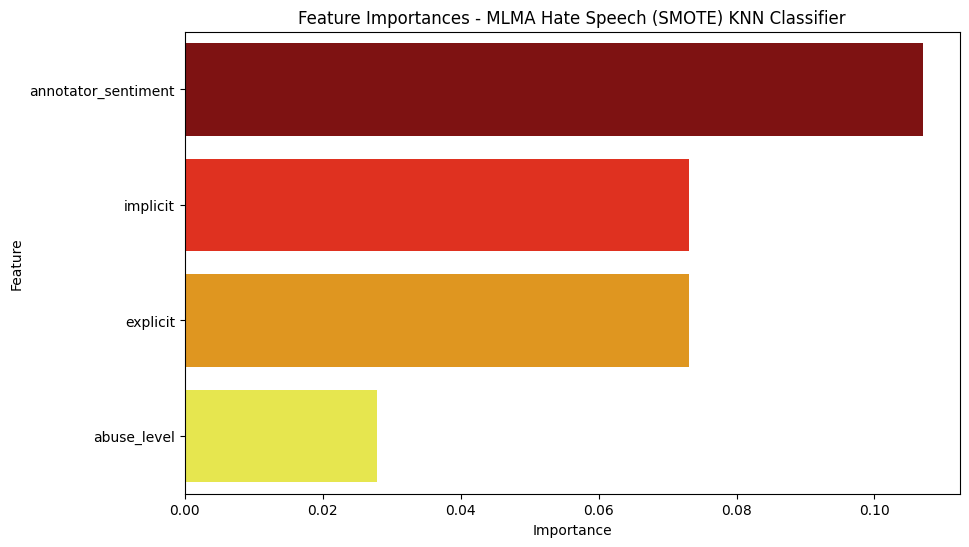

In [113]:
# Plot the feature importances in order
mlma_hate_speech_knn_sorted_importances_df = pd.DataFrame(list(mlma_hate_speech_knn_sorted_feature_importances_dict.items()), columns=['Feature', 'Importance'])
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=mlma_hate_speech_knn_sorted_importances_df, palette='hot')
plt.title(f'Feature Importances - MLMA Hate Speech ({balance}) KNN Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [114]:
# Append details to the results list
knn_classification_results_list.append((
    "K-Nearest Neighbors",
    "MLMA Hate Speech",
    "NA",
    "NA",
    mlma_hate_speech_knn_accuracy,
    mlma_hate_speech_knn_f1,
    0.0,
    mlma_hate_speech_knn_grid_search.best_params_,
    mlma_hate_speech_knn_feature_importances_dict,
    mlma_hate_speech_knn_sorted_feature_importances_dict,
    balance
))

## Support Vector Machine Conclusions

In [115]:
knn_classification_results_list

[('K-Nearest Neighbors',
  'Convabuse',
  'NA',
  'NA',
  0.5985292656265527,
  0.598045776544425,
  0.0,
  {'knn_classifier__metric': 'euclidean',
   'knn_classifier__n_neighbors': 40,
   'knn_classifier__weights': 'distance'},
  {'annotator_id': np.float64(0.128947629931432),
   'bot': np.float64(0.029951306767365606),
   'generalised': np.float64(0.0),
   'individual': np.float64(0.0),
   'system': np.float64(0.002275663321077226),
   'explicit': np.float64(0.19551823511875188),
   'implicit': np.float64(0.09889694921991454),
   'target_groups': np.float64(0.018821425022359152)},
  {'explicit': np.float64(0.19551823511875188),
   'annotator_id': np.float64(0.128947629931432),
   'implicit': np.float64(0.09889694921991454),
   'bot': np.float64(0.029951306767365606),
   'target_groups': np.float64(0.018821425022359152),
   'system': np.float64(0.002275663321077226),
   'generalised': np.float64(0.0),
   'individual': np.float64(0.0)},
  'SMOTE'),
 ('K-Nearest Neighbors',
  'Dynamical

In [116]:
# Convert the knn_classification_results_list to a DataFrame
knn_classification_summary = pd.DataFrame(knn_classification_results_list, columns=["Model", "Dataset", "Kernel", "Regularization", "Accuracy", "F1-score", "Ratio", "Best Parameters", "Importances", "Feature Importances", "Balance"])
knn_classification_summary

,Model,Dataset,Kernel,Regularization,Accuracy,F1-score,Ratio,Best Parameters,Importances,Feature Importances,Balance
0,K-Nearest Neighbors,Convabuse,NA,NA,0.598529,0.598046,0.0,"{'knn_classifier__metric': 'euclidean', 'knn_c...","{'annotator_id': 0.128947629931432, 'bot': 0.0...","{'explicit': 0.19551823511875188, 'annotator_i...",SMOTE
1,K-Nearest Neighbors,Dynamically Generated Hate Speech,NA,NA,0.845812,0.844547,0.0,"{'knn_classifier__metric': 'euclidean', 'knn_c...","{'type': 0.18165680473372778, 'annotator': 0.0...","{'type': 0.18165680473372778, 'target_groups':...",SMOTE
2,K-Nearest Neighbors,Online Abusive Attacks,NA,NA,0.997302,0.997302,0.0,"{'knn_classifier__metric': 'euclidean', 'knn_c...","{'Toxic parent tweets': 0.7241906474820143, 'T...","{'Toxic parent tweets': 0.7241906474820143, 'T...",None
3,K-Nearest Neighbors,US Elections 2020 Hate Speech,NA,NA,0.703598,0.702540,0.0,"{'knn_classifier__metric': 'euclidean', 'knn_c...","{'Trump': 0.16704545454545455, 'Biden': 0.1577...","{'Trump': 0.16704545454545455, 'Biden': 0.1577...",SMOTE
4,K-Nearest Neighbors,MLMA Hate Speech,NA,NA,0.446264,0.440287,0.0,"{'knn_classifier__metric': 'manhattan', 'knn_c...","{'implicit': 0.07315498154981552, 'explicit': ...","{'annotator_sentiment': 0.10702260147601476, '...",SMOTE


In [117]:
knn_classification_summary.to_csv(f"{results_path}/model8_knn-classification-summary_SMOTE.csv", index=False)